# **Proyek Pengganti UAS**  
Anggota Kelompok :  
Christopher Raynard (10122003) \
Muhammad Fikran Naufal (10122097)

## Tujuan

Proyek ini bertujuan untuk membangun model untuk memprediksi seakurat mungkin karir dari para lulusan matematika dengan berbagai model *deep learning* yang telah dipelajari.

## Libraries

In [19]:
import cv2
import os
import glob
from tqdm import tqdm # Progress bar
import librosa
import random
import numpy as np
from math import pi, cos, sin
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from google.colab import drive

In [12]:
from google.colab import drive
drive.mount('/content/drive')
math_df = pd.read_csv('/content/drive/MyDrive/math_job_dataset.csv')
if math_df is not None:
    print('Dataset loaded successfully!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!


## Exploratory Data Analysis

In [13]:
# Display the first 5 rows of the dataset
math_df.head(5)

,job_title,education_level,experience_years,skills_count,industry,company_size,location,remote_work,certifications,salary
0,Operations research analyst,Bachelor,10,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,Bachelor,5,17,Telecom,Small,Australia,No,0,93764
2,Systems analyst,PhD,18,4,Media,Medium,Singapore,No,1,148123
3,Statistician,PhD,19,13,Retail,Medium,Canada,Yes,0,189123
4,Math teacher,Bachelor,15,7,Manufacturing,Large,Sweden,Yes,0,165069


In [14]:
# Display the summary of the dataset
math_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   education_level   250000 non-null  object
 2   experience_years  250000 non-null  int64 
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [15]:
# groupby data from industry to know distribution
math_df.groupby('industry').size()

,0
industry,
Consulting,25258
Education,24889
Finance,25393
Government,24901
Healthcare,24898
Manufacturing,25024
Media,25034
Retail,24841
Technology,24903


In [16]:
math_df.groupby('industry').agg({
    'salary': 'mean'
})

,salary
industry,
Consulting,145451.638293
Education,145993.564547
Finance,145801.639468
Government,145613.869242
Healthcare,145759.995702
Manufacturing,145530.603301
Media,145891.271071
Retail,145399.699408
Technology,145863.808377


<Axes: xlabel='job_title'>

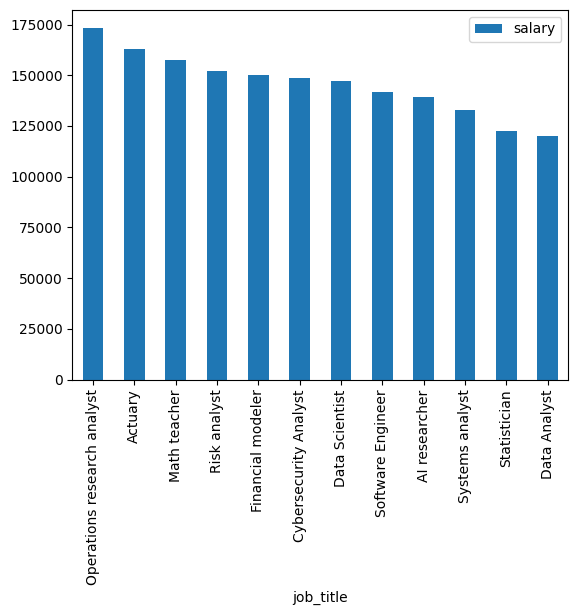

In [31]:
math_df.groupby('job_title').agg({
    'salary': 'mean'
}).sort_values(by='salary', ascending=False).plot(kind='bar')

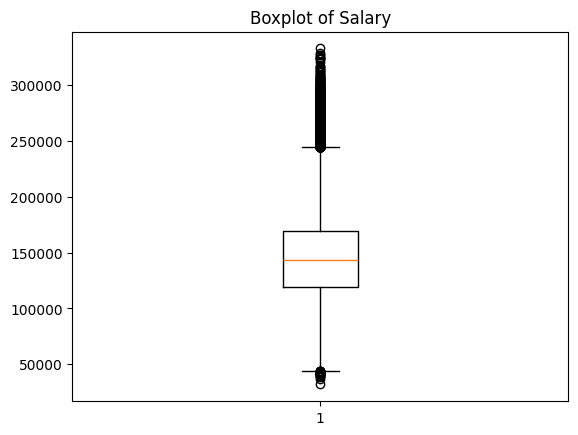

In [27]:
plt.boxplot(math_df['salary'])
plt.title('Boxplot of Salary')
plt.show()

## Feature Engineering

In [17]:
# LabelEncoding
label_encoder = LabelEncoder()

for item in math_df.items():
  # Make new columns for encoded data
  math_df['education_level_encoded'] = label_encoder.fit_transform(math_df['education_level'])
  math_df['company_size_encoded'] = label_encoder.fit_transform(math_df['company_size'])

  # Check encoded results
  display(math_df[['education_level', 'education_level_encoded']].head())
  display(math_df[['company_size', 'company_size_encoded']].head())

,education_level,education_level_encoded
0,Bachelor,0
1,Bachelor,0
2,PhD,4
3,PhD,4
4,Bachelor,0


,company_size,company_size_encoded
0,Medium,2
1,Small,3
2,Medium,2
3,Medium,2
4,Large,1


,education_level,education_level_encoded
0,Bachelor,0
1,Bachelor,0
2,PhD,4
3,PhD,4
4,Bachelor,0


,company_size,company_size_encoded
0,Medium,2
1,Small,3
2,Medium,2
3,Medium,2
4,Large,1


,education_level,education_level_encoded
0,Bachelor,0
1,Bachelor,0
2,PhD,4
3,PhD,4
4,Bachelor,0


...

,company_size,company_size_encoded
0,Medium,2
1,Small,3
2,Medium,2
3,Medium,2
4,Large,1


,education_level,education_level_encoded
0,Bachelor,0
1,Bachelor,0
2,PhD,4
3,PhD,4
4,Bachelor,0


,company_size,company_size_encoded
0,Medium,2
1,Small,3
2,Medium,2
3,Medium,2
4,Large,1


,education_level,education_level_encoded
0,Bachelor,0
1,Bachelor,0
2,PhD,4
3,PhD,4
4,Bachelor,0


,company_size,company_size_encoded
0,Medium,2
1,Small,3
2,Medium,2
3,Medium,2
4,Large,1


In [20]:
# OneHotEncoding
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

for item in math_df.items():
  # Arrays containing one-hot-encoded column data
  industry_encoded_array = onehot_encoder.fit_transform(math_df['industry'])
  work_encoded_array = onehot_encoder.fit_transform(math_df['remote_work'])

  # Get all feature names out from column data
  industry_feature_names = onehot_encoder.get_feature_names_out(['industry'])
  work_feature_names = onehot_encoder.get_feature_names_out(['remote_work'])

  # Make a new dataframe with encoded data
  industry_encoded_df = pd.Dataframe(industry_encoded_array, columns=industry_feature_names, index=df.index)
  work_encoded_df = pd.Dataframe(work_encoded_array, columns=work_feature_names, index=df.index)

  # Concatenate to the original dataframe
  math_df = pd.concat([math_df, industry_encoded_df, work_encoded_df], axis=1)

  # Check encoded results
  display(df[['industry', 'remote_work'] + list(industry_feature_names) + list(work_feature_names)].head())

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

# Model
1. model 1
2. model 2
3. Option 3

## Model 1

In [ ]:
# misalkan mlp klasifikasi